# 16. Classification V: Imbalanced Classification

@Shengli (Bruce) Jiang, University of South Carolina

## What We Have Covered

- Regression, regularization, and model selection
- Feature scaling, encoding, and missing values
- Logistic regression, SVMs, and classification metrics
- Decision trees and random forests

## What We Covered in the Last Lecture

- A decision tree chooses splits that reduce impurity.
- Random forests train different trees using bootstrap samples and random feature subsets.
- Averaging less-correlated tree predictions can reduce variance.

## Today's Learning Objectives

By the end of this notebook, you should be able to:

1. Explain why accuracy can hide missed rare events.
2. Read ROC and precision-recall curves.
3. Choose a threshold on validation data.
4. Compare threshold changes with class-weighted training.

## Running the Notebook

Run the cells from top to bottom. The case study uses the public OpenML sick dataset (ID 38).

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display

Matplotlib is building the font cache; this may take a moment.


## 1. Why Accuracy Can Mislead

Suppose 10 of 1,000 runs have a fault. Predicting *no fault* for every run gives high accuracy but misses every fault.

In [2]:
print("Accuracy:", 990 / 1000)
print("Fault recall:", 0 / 10)

Accuracy: 0.99
Fault recall: 0.0


### A Confusion Matrix

This small example has 9 detected faults, 3 missed faults, and 3 false alarms. We will use it to read the positive-class metrics.

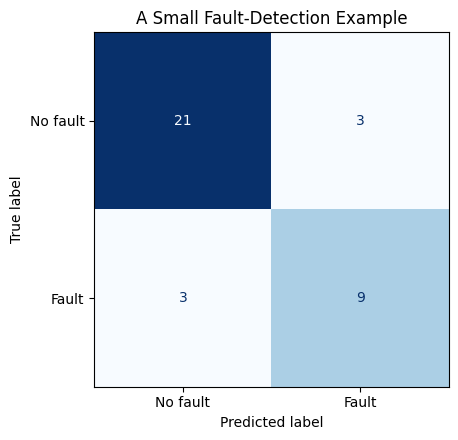

Precision: 0.75
Recall: 0.75
Specificity: 0.875
F1: 0.75


In [3]:
from sklearn.metrics import ConfusionMatrixDisplay

toy_cm = np.array([[21, 3], [3, 9]])
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(toy_cm, display_labels=["No fault", "Fault"]).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format="d"
)
ax.set_title("A Small Fault-Detection Example")
fig.tight_layout()
plt.show()

tn, fp, fn, tp = toy_cm.ravel()
print("Precision:", round(tp / (tp + fp), 3))
print("Recall:", round(tp / (tp + fn), 3))
print("Specificity:", round(tn / (tn + fp), 3))
print("F1:", round(2 * tp / (2 * tp + fp + fn), 3))

For the positive class:

$$\text{Precision}=\frac{TP}{TP+FP},\quad
\text{Recall}=\frac{TP}{TP+FN},\quad
\text{Specificity}=\frac{TN}{TN+FP}.$$

**Check:** If a model predicts every case as negative, what is its positive-class recall? **Answer:** Zero.

## 2. Scores and Thresholds

A classifier first produces a score. We call a sample positive when its predicted probability is at least the threshold. Lowering the threshold labels more samples positive.

,Sample,P(positive),At t=0.50,At t=0.30
0,A,0.90,True,True
1,B,0.65,True,True
2,C,0.48,False,True
3,D,0.30,False,True


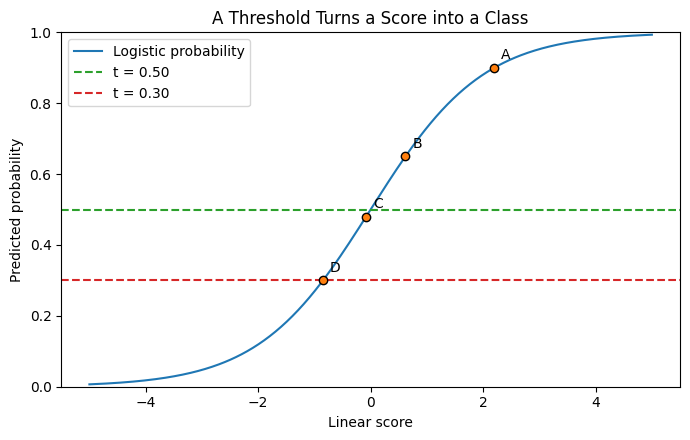

In [4]:
from scipy.special import expit, logit

examples = pd.DataFrame({
    "Sample": ["A", "B", "C", "D"],
    "P(positive)": [0.90, 0.65, 0.48, 0.30]
})
examples["At t=0.50"] = examples["P(positive)"] >= 0.50
examples["At t=0.30"] = examples["P(positive)"] >= 0.30
display(examples)

z = np.linspace(-5, 5, 400)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(z, expit(z), color="C0", label="Logistic probability")
ax.scatter(logit(examples["P(positive)"]), examples["P(positive)"],
           color="C1", edgecolor="black", zorder=3)
for sample, probability in zip(examples["Sample"], examples["P(positive)"]):
    ax.annotate(sample, (logit(probability), probability), xytext=(5, 6),
                textcoords="offset points")
ax.axhline(0.50, color="C2", linestyle="--", label="t = 0.50")
ax.axhline(0.30, color="C3", linestyle="--", label="t = 0.30")
ax.set(xlabel="Linear score", ylabel="Predicted probability",
       title="A Threshold Turns a Score into a Class", ylim=(0, 1))
ax.legend()
fig.tight_layout()
plt.show()

## 3. The ROC Curve

At each threshold, calculate recall (true positive rate) and the false positive rate. One threshold gives one point on the ROC curve.

,Threshold,FPR,Recall
0,inf,0.00,0.00
1,0.92,0.00,0.33
2,0.83,0.33,0.33
3,0.62,0.33,0.67
4,0.57,0.67,0.67
5,0.31,0.67,1.00
6,0.11,1.00,1.00


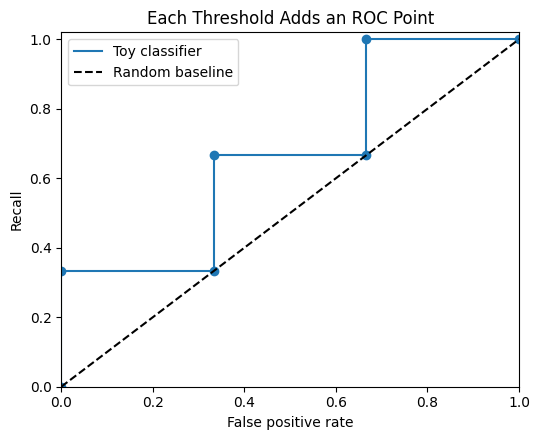

In [5]:
from sklearn.metrics import roc_auc_score, roc_curve

toy_y = np.array([1, 0, 1, 0, 1, 0])
toy_scores = np.array([0.92, 0.83, 0.62, 0.57, 0.31, 0.11])
toy_fpr, toy_tpr, toy_thresholds = roc_curve(toy_y, toy_scores)
display(pd.DataFrame({
    "Threshold": toy_thresholds,
    "FPR": toy_fpr,
    "Recall": toy_tpr
}).round(2))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.step(toy_fpr, toy_tpr, where="post", color="C0", label="Toy classifier")
ax.scatter(toy_fpr, toy_tpr, color="C0")
ax.plot([0, 1], [0, 1], "--", color="black", label="Random baseline")
ax.set(xlabel="False positive rate", ylabel="Recall",
       title="Each Threshold Adds an ROC Point", xlim=(0, 1), ylim=(0, 1.02))
ax.legend()
fig.tight_layout()
plt.show()

### ROC-AUC

The area under the ROC curve summarizes score ranking across thresholds. The shaded plot is illustrative, not a result from the thyroid model.

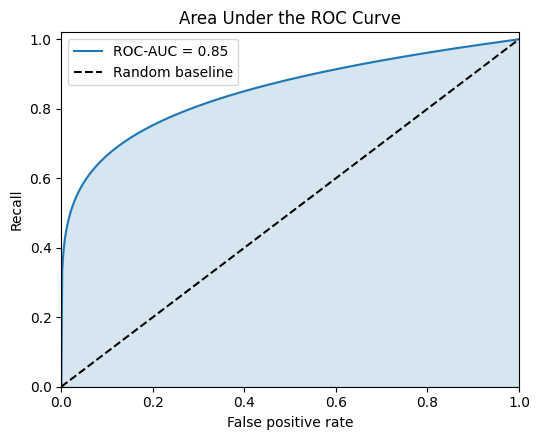

In [6]:
fpr_demo = np.linspace(0, 1, 500)
tpr_demo = fpr_demo ** (1 / 0.85 - 1)
auc_demo = np.trapezoid(tpr_demo, fpr_demo)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.plot(fpr_demo, tpr_demo, color="C0", label=f"ROC-AUC = {auc_demo:.2f}")
ax.fill_between(fpr_demo, tpr_demo, color="C0", alpha=0.18)
ax.plot([0, 1], [0, 1], "--", color="black", label="Random baseline")
ax.set(xlabel="False positive rate", ylabel="Recall", title="Area Under the ROC Curve",
       xlim=(0, 1), ylim=(0, 1.02))
ax.legend()
fig.tight_layout()
plt.show()

### The Same AUC Can Hide Different Operating Points

These illustrative curves show why a single AUC does not tell us which model is better at a particular false positive rate.

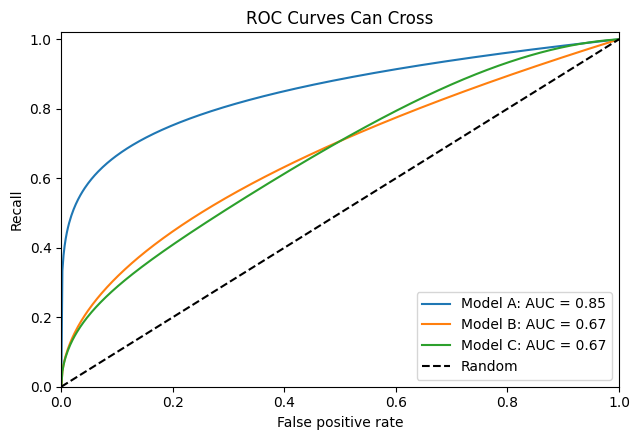

In [7]:
model_a = fpr_demo ** (1 / 0.85 - 1)
model_b = np.sqrt(fpr_demo)
model_c = model_b + 0.8 * fpr_demo * (1 - fpr_demo) * (fpr_demo - 0.5)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for curve, name, color in zip(
    [model_a, model_b, model_c], ["A", "B", "C"], ["C0", "C1", "C2"]
):
    ax.plot(fpr_demo, curve, color=color,
            label=f"Model {name}: AUC = {np.trapezoid(curve, fpr_demo):.2f}")
ax.plot([0, 1], [0, 1], "--", color="black", label="Random")
ax.set(xlabel="False positive rate", ylabel="Recall", title="ROC Curves Can Cross",
       xlim=(0, 1), ylim=(0, 1.02))
ax.legend()
fig.tight_layout()
plt.show()

### Random Scores

Random scores cannot consistently rank positive cases above negative ones. Their ROC curve stays near the diagonal.

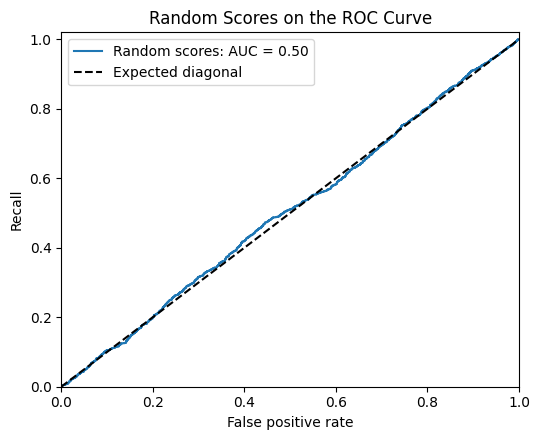

In [8]:
rng = np.random.default_rng(26)
random_y = rng.integers(0, 2, 4000)
random_scores = rng.random(4000)
random_fpr, random_tpr, _ = roc_curve(random_y, random_scores)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.plot(random_fpr, random_tpr, color="C0",
        label=f"Random scores: AUC = {roc_auc_score(random_y, random_scores):.2f}")
ax.plot([0, 1], [0, 1], "--", color="black", label="Expected diagonal")
ax.set(xlabel="False positive rate", ylabel="Recall", title="Random Scores on the ROC Curve",
       xlim=(0, 1), ylim=(0, 1.02))
ax.legend()
fig.tight_layout()
plt.show()

## 4. Why Precision-Recall Matters Here

With many negatives, a small false positive rate can still produce many false alarms. In the next plot, the number of actual negatives stays at 10,000 and true positives stay at 100.

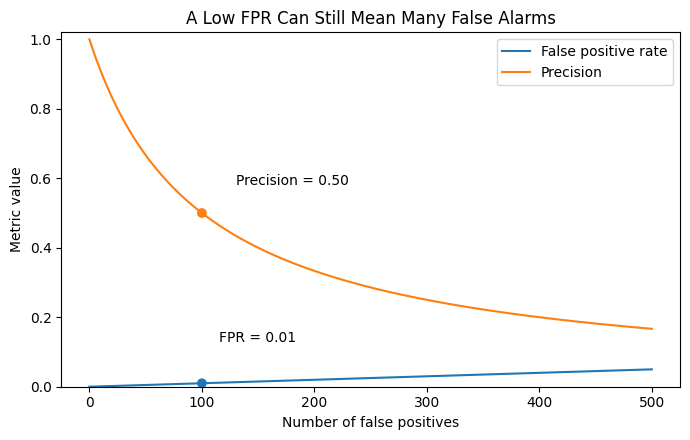

In [9]:
false_positives = np.arange(0, 501)
fpr_values = false_positives / 10000
precision_values = 100 / (100 + false_positives)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(false_positives, fpr_values, color="C0", label="False positive rate")
ax.plot(false_positives, precision_values, color="C1", label="Precision")
ax.scatter([100, 100], [0.01, 0.50], color=["C0", "C1"], zorder=3)
ax.annotate("FPR = 0.01", (100, 0.01), xytext=(115, 0.13))
ax.annotate("Precision = 0.50", (100, 0.50), xytext=(130, 0.58))
ax.set(xlabel="Number of false positives", ylabel="Metric value",
       title="A Low FPR Can Still Mean Many False Alarms", ylim=(0, 1.02))
ax.legend()
fig.tight_layout()
plt.show()

### Comparing Precision-Recall Curves

The three curves below are illustrative. Each reaches the 6% prevalence baseline when recall reaches 1. A useful curve keeps precision high as recall increases.

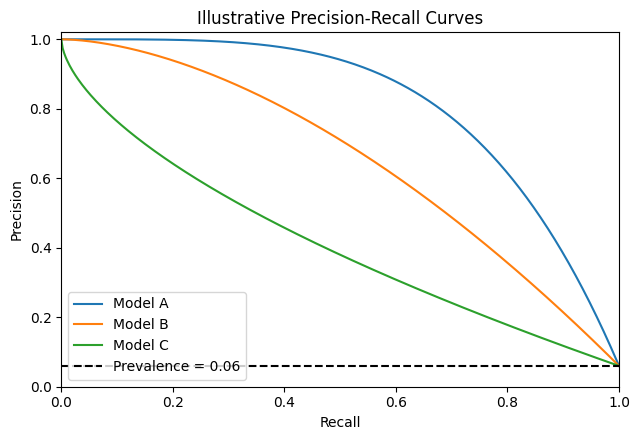

In [10]:
recall_demo = np.linspace(0, 1, 400)
prevalence_demo = 0.06

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for power, name, color in zip([4.0, 1.7, 0.6], ["A", "B", "C"], ["C0", "C1", "C2"]):
    precision_demo = prevalence_demo + (1 - prevalence_demo) * (1 - recall_demo ** power)
    ax.plot(recall_demo, precision_demo, color=color, label=f"Model {name}")
ax.axhline(prevalence_demo, color="black", linestyle="--", label="Prevalence = 0.06")
ax.set(xlabel="Recall", ylabel="Precision", title="Illustrative Precision-Recall Curves",
       xlim=(0, 1), ylim=(0, 1.02))
ax.legend()
fig.tight_layout()
plt.show()

### Average Precision

Average precision (AP) adds the precision at each increase in recall:

$$AP=\sum_n (R_n-R_{n-1})P_n.$$

The shaded rectangles show this calculation for an illustrative curve.

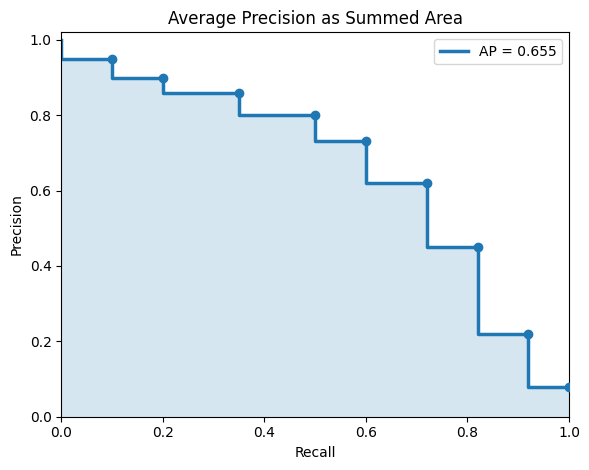

In [11]:
recall_steps = np.array([0.00, 0.10, 0.20, 0.35, 0.50,
                         0.60, 0.72, 0.82, 0.92, 1.00])
precision_steps = np.array([1.00, 0.95, 0.90, 0.86, 0.80,
                            0.732, 0.62, 0.45, 0.22, 0.08])
delta_recall = np.diff(recall_steps)
ap_demo = np.sum(delta_recall * precision_steps[1:])

fig, ax = plt.subplots(figsize=(6, 4.8))
ax.bar(recall_steps[:-1], precision_steps[1:], width=delta_recall,
       align="edge", color="C0", alpha=0.18, edgecolor="none")
ax.step(recall_steps, precision_steps, where="pre", color="C0",
        linewidth=2.5, label=f"AP = {ap_demo:.3f}")
ax.scatter(recall_steps[1:], precision_steps[1:], color="C0", zorder=3)
ax.set(xlabel="Recall", ylabel="Precision", title="Average Precision as Summed Area",
       xlim=(0, 1), ylim=(0, 1.02))
ax.legend()
fig.tight_layout()
plt.show()

## 5. Thyroid “Sick” Case Study

We now use one real dataset for the rest of the notebook. The positive class is `sick`.

,Count
Negative,3541
Sick,231


Samples: 3772
Features used: 26
Positive prevalence: 0.061


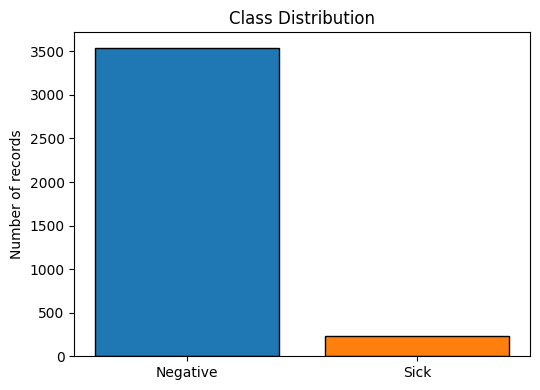

In [12]:
from sklearn.datasets import fetch_openml

data = fetch_openml(data_id=38, as_frame=True)
X = data.data.drop(columns=["sick", "TBG", "TBG_measured"])
y = (data.target.astype(str) == "sick").astype(int)

class_counts = pd.Series({"Negative": (y == 0).sum(), "Sick": (y == 1).sum()})
display(class_counts.to_frame("Count"))
print("Samples:", len(y))
print("Features used:", X.shape[1])
print("Positive prevalence:", round(y.mean(), 3))

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.bar(class_counts.index, class_counts.values, color=["C0", "C1"], edgecolor="black")
ax.set(ylabel="Number of records", title="Class Distribution")
fig.tight_layout()
plt.show()

The raw OpenML table has 29 input fields. We remove the `sick` input field, all-missing `TBG`, and constant `TBG_measured` field, leaving 26 predictors. The target is separate from the predictors.

### Split Before Fitting Preprocessing

Reserve 20% for the final test. Split the remaining data into training and validation sets. Stratification keeps the class proportion similar in each split.

In [13]:
from sklearn.model_selection import train_test_split

X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=26
)
X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev, test_size=0.25, stratify=y_dev, random_state=26
)

split_counts = pd.DataFrame({
    "Split": ["Training", "Validation", "Test"],
    "Samples": [len(y_train), len(y_val), len(y_test)],
    "Positive": [y_train.sum(), y_val.sum(), y_test.sum()]
})
split_counts["Positive fraction"] = split_counts["Positive"] / split_counts["Samples"]
display(split_counts.round(3))

,Split,Samples,Positive,Positive fraction
0,Training,2262,139,0.061
1,Validation,755,46,0.061
2,Test,755,46,0.061


### Preprocessing Pipeline

Numerical fields receive median imputation and scaling. Categorical fields receive most-frequent imputation and one-hot encoding. The pipeline learns these steps from training data only.

In [14]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
preprocess = ColumnTransformer([
    ("numeric", numeric, make_column_selector(dtype_include=np.number)),
    ("categorical", categorical, make_column_selector(dtype_exclude=np.number))
])

## 6. Logistic Regression Baseline

Fit the model on training data. We first evaluate on validation data at the default threshold of 0.5.

In [15]:
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score
)


def metric_row(name, y_true, prediction, score):
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, prediction),
        "Precision": precision_score(y_true, prediction, zero_division=0),
        "Recall": recall_score(y_true, prediction, zero_division=0),
        "F1": f1_score(y_true, prediction, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, score),
        "AP": average_precision_score(y_true, score),
        "FP": fp,
        "FN": fn
    }


logistic = Pipeline([
    ("preprocess", clone(preprocess)),
    ("model", LogisticRegression(max_iter=2000))
])
logistic.fit(X_train, y_train)
p_val = logistic.predict_proba(X_val)[:, 1]
pred_val = (p_val >= 0.5).astype(int)
display(pd.DataFrame([metric_row("Logistic, t=0.5", y_val, pred_val, p_val)]).round(3))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,AP,FP,FN
0,"Logistic, t=0.5",0.96,0.7,0.609,0.651,0.961,0.656,12,18


### ROC and Precision-Recall on Validation Data

ROC shows recall against false positive rate. PR shows precision against recall. The PR baseline is the positive prevalence in the validation set.

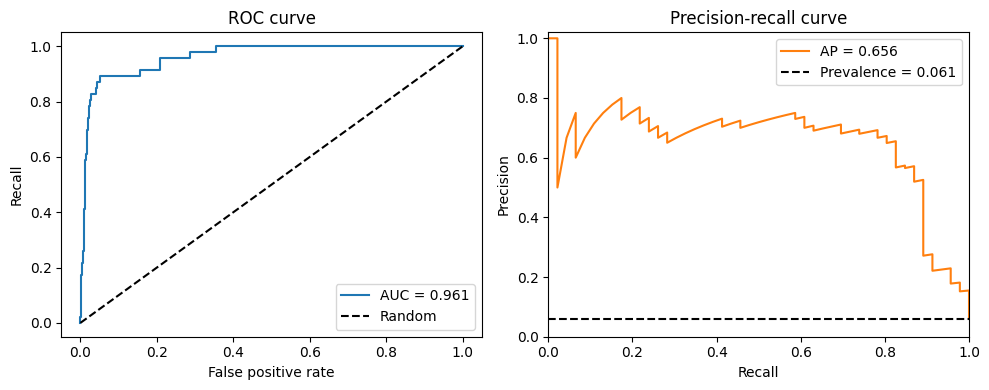

In [16]:
from sklearn.metrics import precision_recall_curve

fpr, tpr, _ = roc_curve(y_val, p_val)
precision, recall, _ = precision_recall_curve(y_val, p_val)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(fpr, tpr, color="C0", label=f"AUC = {roc_auc_score(y_val, p_val):.3f}")
ax[0].plot([0, 1], [0, 1], "--", color="black", label="Random")
ax[0].set(xlabel="False positive rate", ylabel="Recall", title="ROC curve")
ax[0].legend()

ax[1].plot(recall, precision, color="C1",
           label=f"AP = {average_precision_score(y_val, p_val):.3f}")
ax[1].axhline(y_val.mean(), linestyle="--", color="black",
              label=f"Prevalence = {y_val.mean():.3f}")
ax[1].set(xlabel="Recall", ylabel="Precision", title="Precision-recall curve",
          xlim=(0, 1), ylim=(0, 1.02))
ax[1].legend()

fig.tight_layout()
plt.show()

## 7. Threshold Choice

The scores stay fixed as we change the threshold. Precision, recall, and the confusion counts can change. ROC-AUC and AP stay the same.

,Model,Precision,Recall,F1,FP,FN
0,t=0.10,0.466,0.891,0.612,47,5
1,t=0.20,0.563,0.870,0.684,31,6
2,t=0.30,0.673,0.804,0.733,18,9
3,t=0.50,0.700,0.609,0.651,12,18
4,t=0.70,0.720,0.391,0.507,7,28


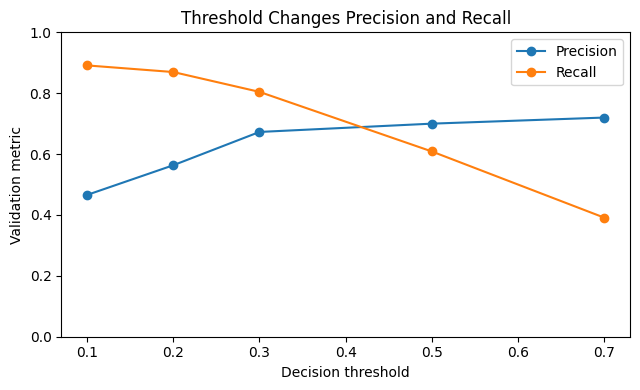

In [17]:
threshold_rows = []
for threshold in [0.10, 0.20, 0.30, 0.50, 0.70]:
    prediction = (p_val >= threshold).astype(int)
    row = metric_row(f"t={threshold:.2f}", y_val, prediction, p_val)
    threshold_rows.append({key: row[key] for key in
                           ["Model", "Precision", "Recall", "F1", "FP", "FN"]})

threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table.round(3))

threshold_values = np.array([0.10, 0.20, 0.30, 0.50, 0.70])
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(threshold_values, threshold_table["Precision"], "o-", color="C0", label="Precision")
ax.plot(threshold_values, threshold_table["Recall"], "o-", color="C1", label="Recall")
ax.set(xlabel="Decision threshold", ylabel="Validation metric",
       title="Threshold Changes Precision and Recall", ylim=(0, 1))
ax.legend()
fig.tight_layout()
plt.show()

For this classroom example, choose the validation threshold with the highest precision among points that reach at least 80% recall. Then leave that threshold fixed for the test set.

In [18]:
precision_curve, recall_curve, thresholds = precision_recall_curve(y_val, p_val)
valid = recall_curve[:-1] >= 0.80
best_index = np.argmax(np.where(valid, precision_curve[:-1], -1))
chosen_threshold = thresholds[best_index]

print("Chosen validation threshold:", round(chosen_threshold, 3))
display(pd.DataFrame([
    metric_row("Default t=0.5", y_val, (p_val >= 0.5).astype(int), p_val),
    metric_row("Chosen threshold", y_val, (p_val >= chosen_threshold).astype(int), p_val)
]).round(3))

Chosen validation threshold: 0.316


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,AP,FP,FN
0,Default t=0.5,0.960,0.700,0.609,0.651,0.961,0.656,12,18
1,Chosen threshold,0.964,0.673,0.804,0.733,0.961,0.656,18,9


## 8. Class-Weighted Logistic Regression

`class_weight="balanced"` gives more training weight to the rare class. Unlike moving the threshold, weighting fits a different model.

In [19]:
train_counts = y_train.value_counts().sort_index()
class_weights = len(y_train) / (2 * train_counts)
display(pd.DataFrame({"Training count": train_counts,
                      "Balanced weight": class_weights}).round(2))

weighted_logistic = Pipeline([
    ("preprocess", clone(preprocess)),
    ("model", LogisticRegression(class_weight="balanced", max_iter=2000))
])
weighted_logistic.fit(X_train, y_train)
p_weighted_val = weighted_logistic.predict_proba(X_val)[:, 1]

display(pd.DataFrame([
    metric_row("Ordinary logistic", y_val, logistic.predict(X_val), p_val),
    metric_row("Weighted logistic", y_val,
               weighted_logistic.predict(X_val), p_weighted_val)
]).round(3))

,Training count,Balanced weight
Class,,
0,2123,0.53
1,139,8.14


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,AP,FP,FN
0,Ordinary logistic,0.960,0.70,0.609,0.651,0.961,0.656,12,18
1,Weighted logistic,0.898,0.36,0.870,0.510,0.952,0.608,71,6


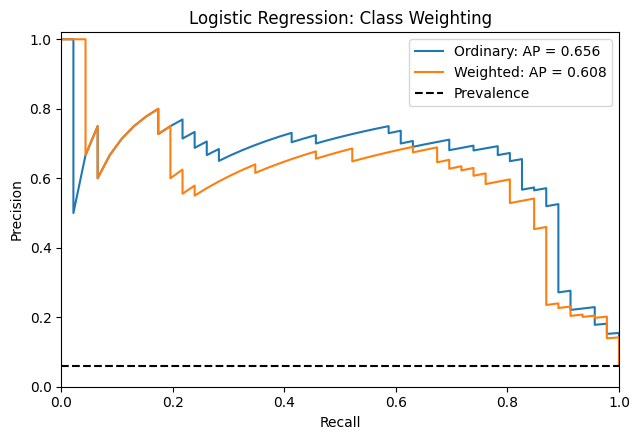

In [20]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for name, scores, color in [
    ("Ordinary", p_val, "C0"),
    ("Weighted", p_weighted_val, "C1")
]:
    p_curve, r_curve, _ = precision_recall_curve(y_val, scores)
    ap = average_precision_score(y_val, scores)
    ax.plot(r_curve, p_curve, color=color, label=f"{name}: AP = {ap:.3f}")
ax.axhline(y_val.mean(), linestyle="--", color="black", label="Prevalence")
ax.set(xlabel="Recall", ylabel="Precision", title="Logistic Regression: Class Weighting",
       xlim=(0, 1), ylim=(0, 1.02))
ax.legend()
fig.tight_layout()
plt.show()

The curve shows score ranking. The confusion matrices below show the class predictions at the default threshold of 0.5.

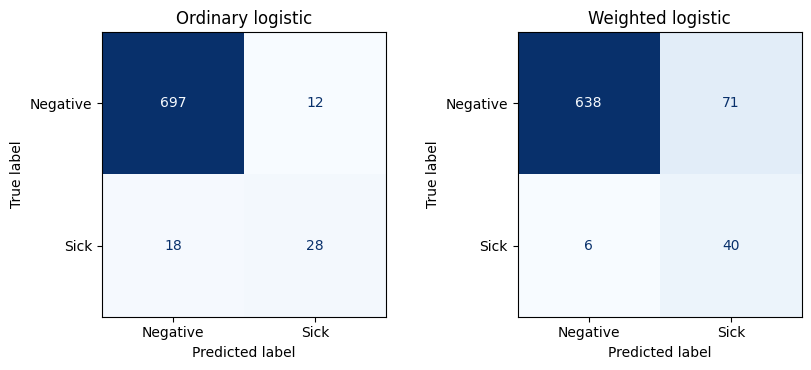

In [21]:
def confusion_pair(y_true, left_pred, right_pred, left_title, right_title):
    fig, ax = plt.subplots(1, 2, figsize=(8.5, 3.8))
    for axis, prediction, title in zip(
        ax, [left_pred, right_pred], [left_title, right_title]
    ):
        ConfusionMatrixDisplay.from_predictions(
            y_true, prediction, labels=[0, 1],
            display_labels=["Negative", "Sick"],
            cmap="Blues", colorbar=False, values_format="d", ax=axis
        )
        axis.set_title(title)
    fig.tight_layout()
    plt.show()


confusion_pair(y_val, logistic.predict(X_val), weighted_logistic.predict(X_val),
               "Ordinary logistic", "Weighted logistic")

**Quiz 3.** Weighting reduces missed sick cases but raises false alarms. Is the weighted model automatically better?

**Answer:** No. The choice depends on the cost of each error and the required operating point.

## 9. The Same Comparison with an RBF SVM

The SVM's `decision_function` gives scores for ROC and PR curves. Its default class predictions give the confusion matrix.

In [22]:
from sklearn.svm import SVC


def fitted_pipeline(estimator):
    model = Pipeline([("preprocess", clone(preprocess)), ("model", estimator)])
    return model.fit(X_train, y_train)


svm_normal = fitted_pipeline(SVC(kernel="rbf", C=1, gamma="scale"))
svm_weighted = fitted_pipeline(
    SVC(kernel="rbf", C=1, gamma="scale", class_weight="balanced")
)
svm_score_normal = svm_normal.decision_function(X_val)
svm_score_weighted = svm_weighted.decision_function(X_val)

display(pd.DataFrame([
    metric_row("RBF SVM", y_val, svm_normal.predict(X_val), svm_score_normal),
    metric_row("Weighted RBF SVM", y_val,
               svm_weighted.predict(X_val), svm_score_weighted)
]).round(3))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,AP,FP,FN
0,RBF SVM,0.966,0.778,0.609,0.683,0.981,0.823,8,18
1,Weighted RBF SVM,0.952,0.562,0.978,0.714,0.987,0.775,35,1


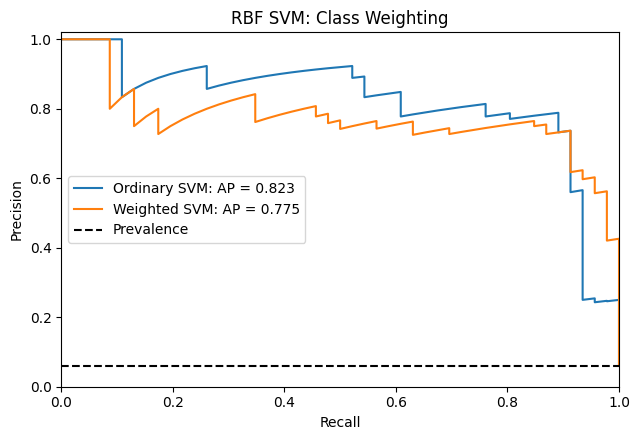

In [23]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for name, scores, color in [
    ("Ordinary SVM", svm_score_normal, "C0"),
    ("Weighted SVM", svm_score_weighted, "C1")
]:
    p_curve, r_curve, _ = precision_recall_curve(y_val, scores)
    ax.plot(r_curve, p_curve, color=color,
            label=f"{name}: AP = {average_precision_score(y_val, scores):.3f}")
ax.axhline(y_val.mean(), color="black", linestyle="--", label="Prevalence")
ax.set(xlabel="Recall", ylabel="Precision", title="RBF SVM: Class Weighting",
       xlim=(0, 1), ylim=(0, 1.02))
ax.legend()
fig.tight_layout()
plt.show()

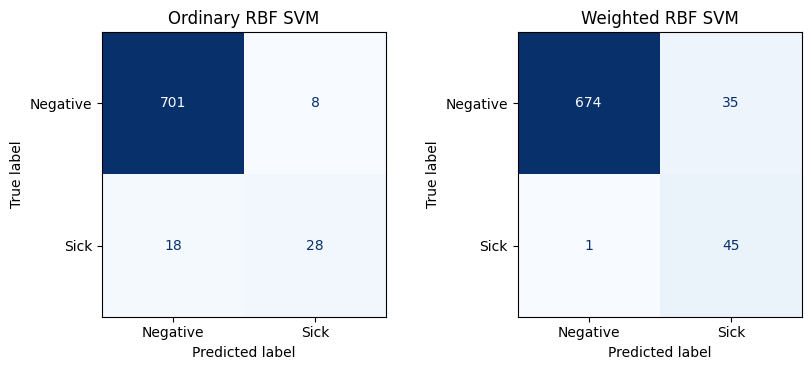

In [24]:
confusion_pair(y_val, svm_normal.predict(X_val), svm_weighted.predict(X_val),
               "Ordinary RBF SVM", "Weighted RBF SVM")

## 10. The Same Comparison with a Random Forest

The forest gives positive-class probabilities with `predict_proba`. Weighting can change its fitted trees, but it need not improve every metric.

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_normal = fitted_pipeline(
    RandomForestClassifier(n_estimators=150, random_state=26, n_jobs=-1)
)
rf_weighted = fitted_pipeline(
    RandomForestClassifier(n_estimators=150, class_weight="balanced",
                           random_state=26, n_jobs=-1)
)
rf_score_normal = rf_normal.predict_proba(X_val)[:, 1]
rf_score_weighted = rf_weighted.predict_proba(X_val)[:, 1]

display(pd.DataFrame([
    metric_row("Random forest", y_val, rf_normal.predict(X_val), rf_score_normal),
    metric_row("Weighted forest", y_val,
               rf_weighted.predict(X_val), rf_score_weighted)
]).round(3))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,AP,FP,FN
0,Random forest,0.983,0.902,0.804,0.851,0.995,0.941,4,9
1,Weighted forest,0.983,0.851,0.870,0.860,0.996,0.949,7,6


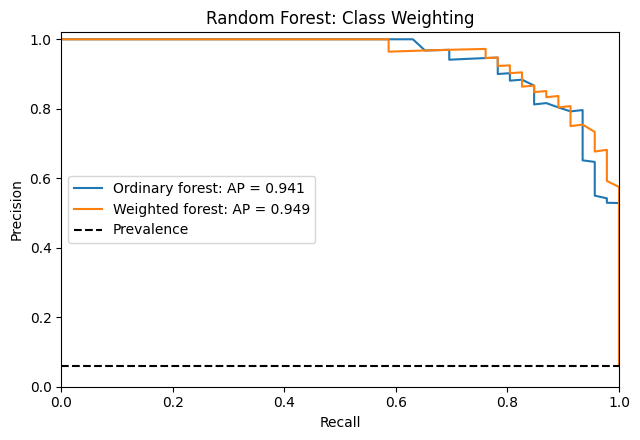

In [26]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for name, scores, color in [
    ("Ordinary forest", rf_score_normal, "C0"),
    ("Weighted forest", rf_score_weighted, "C1")
]:
    p_curve, r_curve, _ = precision_recall_curve(y_val, scores)
    ax.plot(r_curve, p_curve, color=color,
            label=f"{name}: AP = {average_precision_score(y_val, scores):.3f}")
ax.axhline(y_val.mean(), color="black", linestyle="--", label="Prevalence")
ax.set(xlabel="Recall", ylabel="Precision", title="Random Forest: Class Weighting",
       xlim=(0, 1), ylim=(0, 1.02))
ax.legend()
fig.tight_layout()
plt.show()

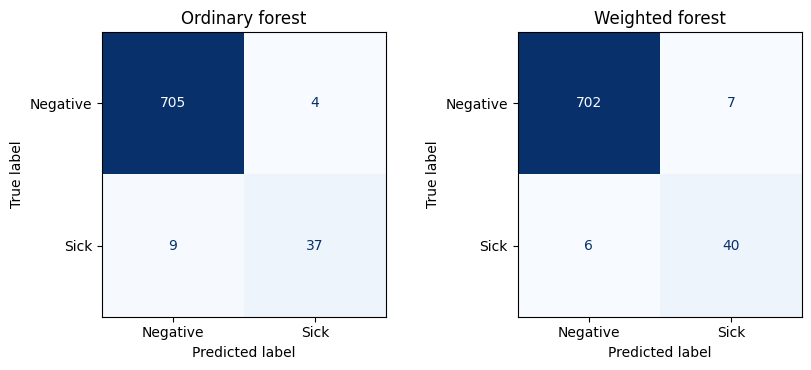

In [27]:
confusion_pair(y_val, rf_normal.predict(X_val), rf_weighted.predict(X_val),
               "Ordinary forest", "Weighted forest")

## 11. Compare Models on Validation Data

Compare error counts and curves before making a choice. The models can have different score scales, but ROC-AUC and AP use each model's ranking.

In [28]:
comparison_rows = [
    metric_row("Logistic", y_val, logistic.predict(X_val), p_val),
    metric_row("Weighted logistic", y_val,
               weighted_logistic.predict(X_val), p_weighted_val),
    metric_row("RBF SVM", y_val, svm_normal.predict(X_val), svm_score_normal),
    metric_row("Weighted RBF SVM", y_val,
               svm_weighted.predict(X_val), svm_score_weighted),
    metric_row("Random forest", y_val, rf_normal.predict(X_val), rf_score_normal),
    metric_row("Weighted forest", y_val,
               rf_weighted.predict(X_val), rf_score_weighted)
]
comparison = pd.DataFrame(comparison_rows)
display(comparison.round(3))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,AP,FP,FN
0,Logistic,0.960,0.700,0.609,0.651,0.961,0.656,12,18
1,Weighted logistic,0.898,0.360,0.870,0.510,0.952,0.608,71,6
2,RBF SVM,0.966,0.778,0.609,0.683,0.981,0.823,8,18
3,Weighted RBF SVM,0.952,0.562,0.978,0.714,0.987,0.775,35,1
4,Random forest,0.983,0.902,0.804,0.851,0.995,0.941,4,9
5,Weighted forest,0.983,0.851,0.870,0.860,0.996,0.949,7,6


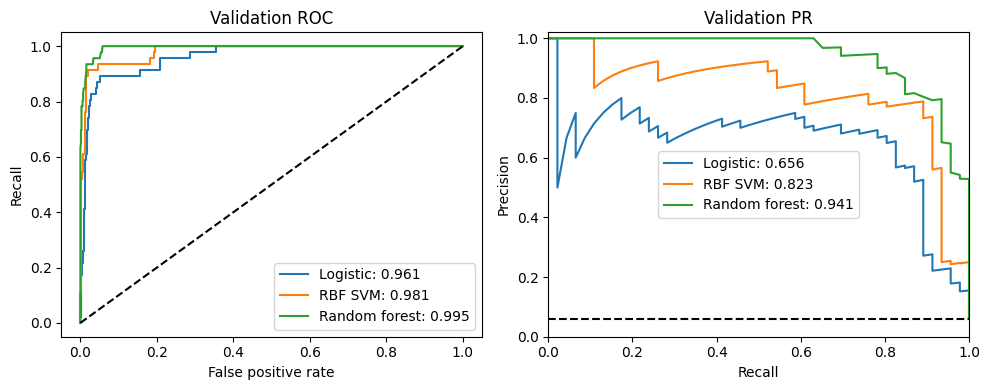

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for name, scores, color in [
    ("Logistic", p_val, "C0"),
    ("RBF SVM", svm_score_normal, "C1"),
    ("Random forest", rf_score_normal, "C2")
]:
    model_fpr, model_tpr, _ = roc_curve(y_val, scores)
    model_p, model_r, _ = precision_recall_curve(y_val, scores)
    ax[0].plot(model_fpr, model_tpr, color=color,
               label=f"{name}: {roc_auc_score(y_val, scores):.3f}")
    ax[1].plot(model_r, model_p, color=color,
               label=f"{name}: {average_precision_score(y_val, scores):.3f}")
ax[0].plot([0, 1], [0, 1], "--", color="black")
ax[0].set(xlabel="False positive rate", ylabel="Recall", title="Validation ROC")
ax[1].axhline(y_val.mean(), color="black", linestyle="--")
ax[1].set(xlabel="Recall", ylabel="Precision", title="Validation PR",
          xlim=(0, 1), ylim=(0, 1.02))
for axis in ax:
    axis.legend()
fig.tight_layout()
plt.show()

## 12. Final Test Evaluation

For the threshold example, keep the ordinary logistic model and the threshold chosen on validation data. Evaluate this fixed choice on test data once.

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,AP,FP,FN
0,"Logistic, chosen threshold",0.968,0.72,0.783,0.75,0.947,0.704,14,10


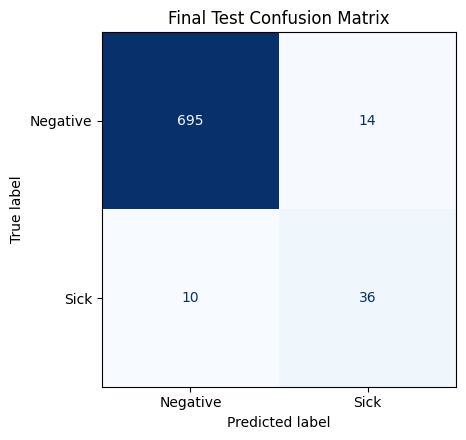

In [30]:
p_test = logistic.predict_proba(X_test)[:, 1]
pred_test = (p_test >= chosen_threshold).astype(int)
display(pd.DataFrame([
    metric_row("Logistic, chosen threshold", y_test, pred_test, p_test)
]).round(3))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_test, labels=[0, 1],
    display_labels=["Negative", "Sick"],
    cmap="Blues", colorbar=False, values_format="d", ax=ax
)
ax.set_title("Final Test Confusion Matrix")
fig.tight_layout()
plt.show()